# Setup

In [1]:
lapply(c('viridis', 'ggthemes', 'skimr'),
       function(pkg_name) { if(! pkg_name %in% installed.packages()) { install.packages(pkg_name)} } )

library(viridis)    # A nice color scheme for plots.
library(ggthemes)   # Common themes to change the look and feel of plots.
library(scales)     # Graphical scales map data to aesthetics in plots.
library(skimr)      # Better summaries of data.
library(lubridate)  # Date library from the tidyverse.
library(tidyverse)  # Data wrangling packages.
library(bigrquery)  # Data extraction from Google BigQuery
library(data.table )

# Load required libraries
library(dplyr)
library(tidyr)
library(purrr)
library(broom)

## Plot setup.
theme_set(theme_bw(base_size = 14)) # Default theme for plots.

#' Returns a data frame with a y position and a label, for use annotating ggplot boxplots.
#'
#' @param d A data frame.
#' @return A data frame with column y as max and column label as length.
get_boxplot_fun_data <- function(df) {
  return(data.frame(y = max(df), label = stringr::str_c('N = ', length(df))))
}

# Get the bucket name
my_bucket <- Sys.getenv('WORKSPACE_BUCKET')

[[1]]
NULL

[[2]]
NULL

[[3]]
NULL

Loading required package: viridisLite


Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr   1.1.4     ✔ readr   2.1.5
✔ forcats 1.0.0     ✔ stringr 1.5.1
✔ ggplot2 3.5.2     ✔ tibble  3.2.1
✔ purrr   1.0.4     ✔ tidyr   1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor() masks scales::col_factor()
✖ purrr::discard()    masks scales::discard()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is

In [2]:
name_of_file_in_bucket <- 'All_SDoH_data_domain_filtered_60.csv'

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)

# Load the file into a dataframe
sdoh_data  <- read_csv(name_of_file_in_bucket)

character(0)

Rows: 54313 Columns: 54
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (6): SexGender, where_born, military, healthcare, disabled, sexual_ori...
dbl  (37): person_id, race_unknown, age_today, LGBTQIA, ehr_length, relative...
lgl   (8): AIAN, Asian, Black, Mid, Multiple, PI, White, His
date  (3): date_of_birth, min_date, max_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Load and merge data

In [3]:
# Make one-hot encoded columns for each level of SexGender
sdoh_data  <- sdoh_data  %>%
  mutate(SexGender = as.factor(SexGender)) %>%
  mutate(dummy = 1) %>%
  pivot_wider(
    names_from = SexGender,
    values_from = dummy,
    values_fill = 0,
    names_prefix = ""
  )

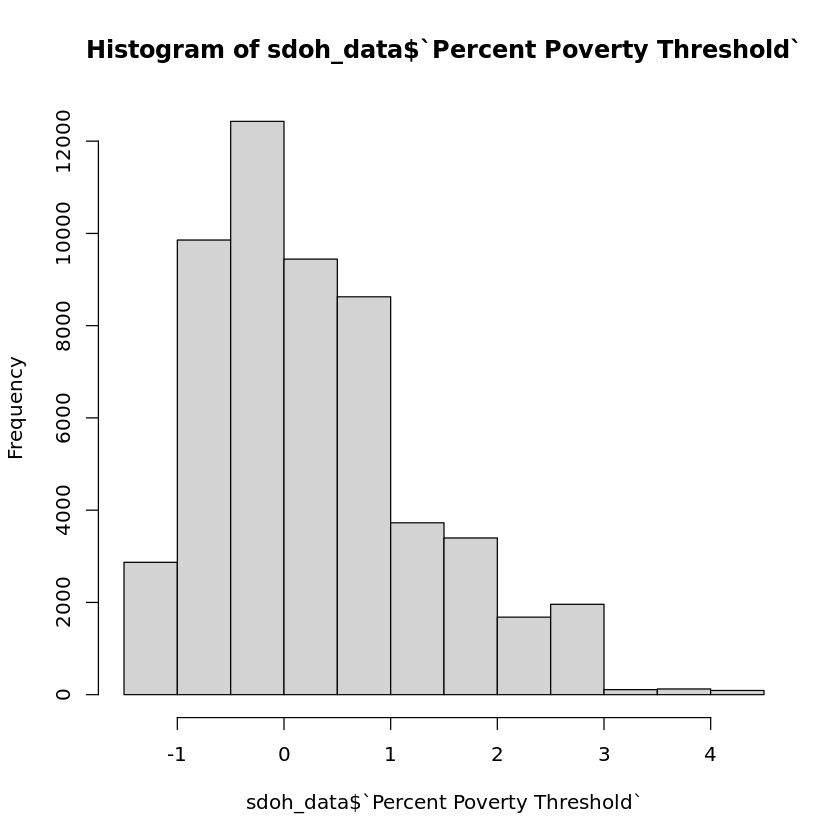

In [4]:
hist(sdoh_data$`Percent Poverty Threshold`)

## Set up lists

In [5]:
SCC<-c("Social Support", "Loneliness", "Social Cohesion", "Everyday Discrimination", "Stress", "Spiritual Experiences")
NBE<-c("Crime", "Physical Disorder", "Social Disorder", "Walkability")
ES<-c("Own Home","Housing Quality", "Housing Instability", "Food Insecurity", "Percent Poverty Threshold")
HCAU<-c("Health Literacy", "Medical Discrimination", "Health Coverage", "Healthcare Utilization",
        "Delayed Care", "Can\'t afford care", "Worried Pay", "Respect")
education<-c("Education")
covariates<-c("visit_frequency", "record_depth", "age", "Cis_male", "Cis_female", "SGM")
domains <-c(SCC, NBE, ES, HCAU, education)
all_domains<-c(SCC, NBE, ES, HCAU, education, covariates)

# Correlation Matrix

In [6]:
All_SDoH_data_cor <- sdoh_data[, all_domains]

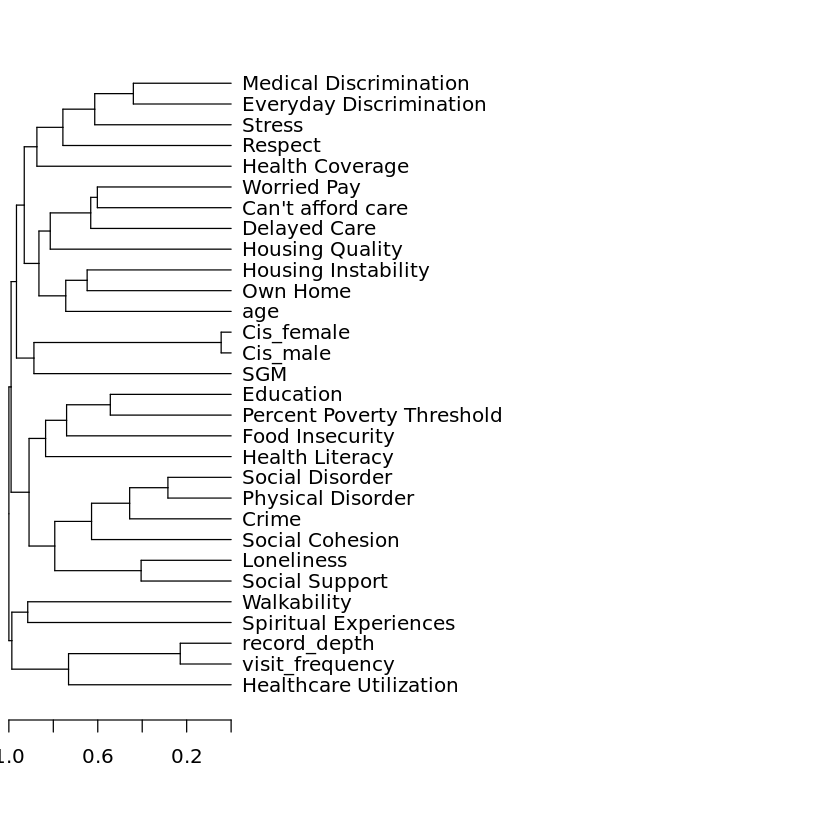

In [7]:
cor_matrix <- cor(All_SDoH_data_cor, use = "pairwise.complete.obs")

# Compute hierarchical clustering
hc <- hclust(as.dist(1 - abs(cor_matrix)), method = "complete")

# Convert to dendrogram object
dend <- as.dendrogram(hc)

# Plot the rotated dendrogram
par(mar = c(5, 0, 2, 25))  # Adjust the margin for the bottom, left, top, and right sides respectively
plot(dend, horiz = TRUE)

In [8]:
# Assuming cor_matrix is your correlation matrix

# Get dimensions and column names of the matrix
n <- nrow(cor_matrix)
col_names <- colnames(cor_matrix)

# Get upper triangle indices (excluding diagonal)
upper_tri_indices <- which(upper.tri(cor_matrix, diag = FALSE), arr.ind = TRUE)

# Extract upper triangle values and corresponding row/column names
cor_values <- round(cor_matrix[upper_tri_indices],2)
row_names <- rownames(cor_matrix)[upper_tri_indices[, 1]]
col_names <- col_names[upper_tri_indices[, 2]]

# Combine row and column names with their respective correlation values
cor_data <- data.frame(
  Pair = paste(row_names, col_names, sep = " & "),
  Correlation = cor_values
)

# Sort by correlation value in descending order
cor_data_sorted <- cor_data[order(-abs(cor_data$Correlation)), ]

# Select top 20 correlations
top_20 <- cor_data_sorted[1:50, ]

# Print the top 
print(top_20)

                                                Pair Correlation
406                            Cis_male & Cis_female       -0.96
325                   visit_frequency & record_depth        0.77
36               Physical Disorder & Social Disorder        0.72
35                           Crime & Social Disorder        0.63
1                        Social Support & Loneliness       -0.60
8                                Loneliness & Stress        0.56
124 Everyday Discrimination & Medical Discrimination        0.56
28                         Crime & Physical Disorder        0.54
31                 Social Cohesion & Social Disorder       -0.53
10                  Everyday Discrimination & Stress        0.49
268            Percent Poverty Threshold & Education        0.46
5               Loneliness & Everyday Discrimination        0.44
231                  Can't afford care & Worried Pay        0.40
24               Social Cohesion & Physical Disorder       -0.39
125                  Stre


Attaching package: ‘gplots’


The following object is masked from ‘package:stats’:

    lowess




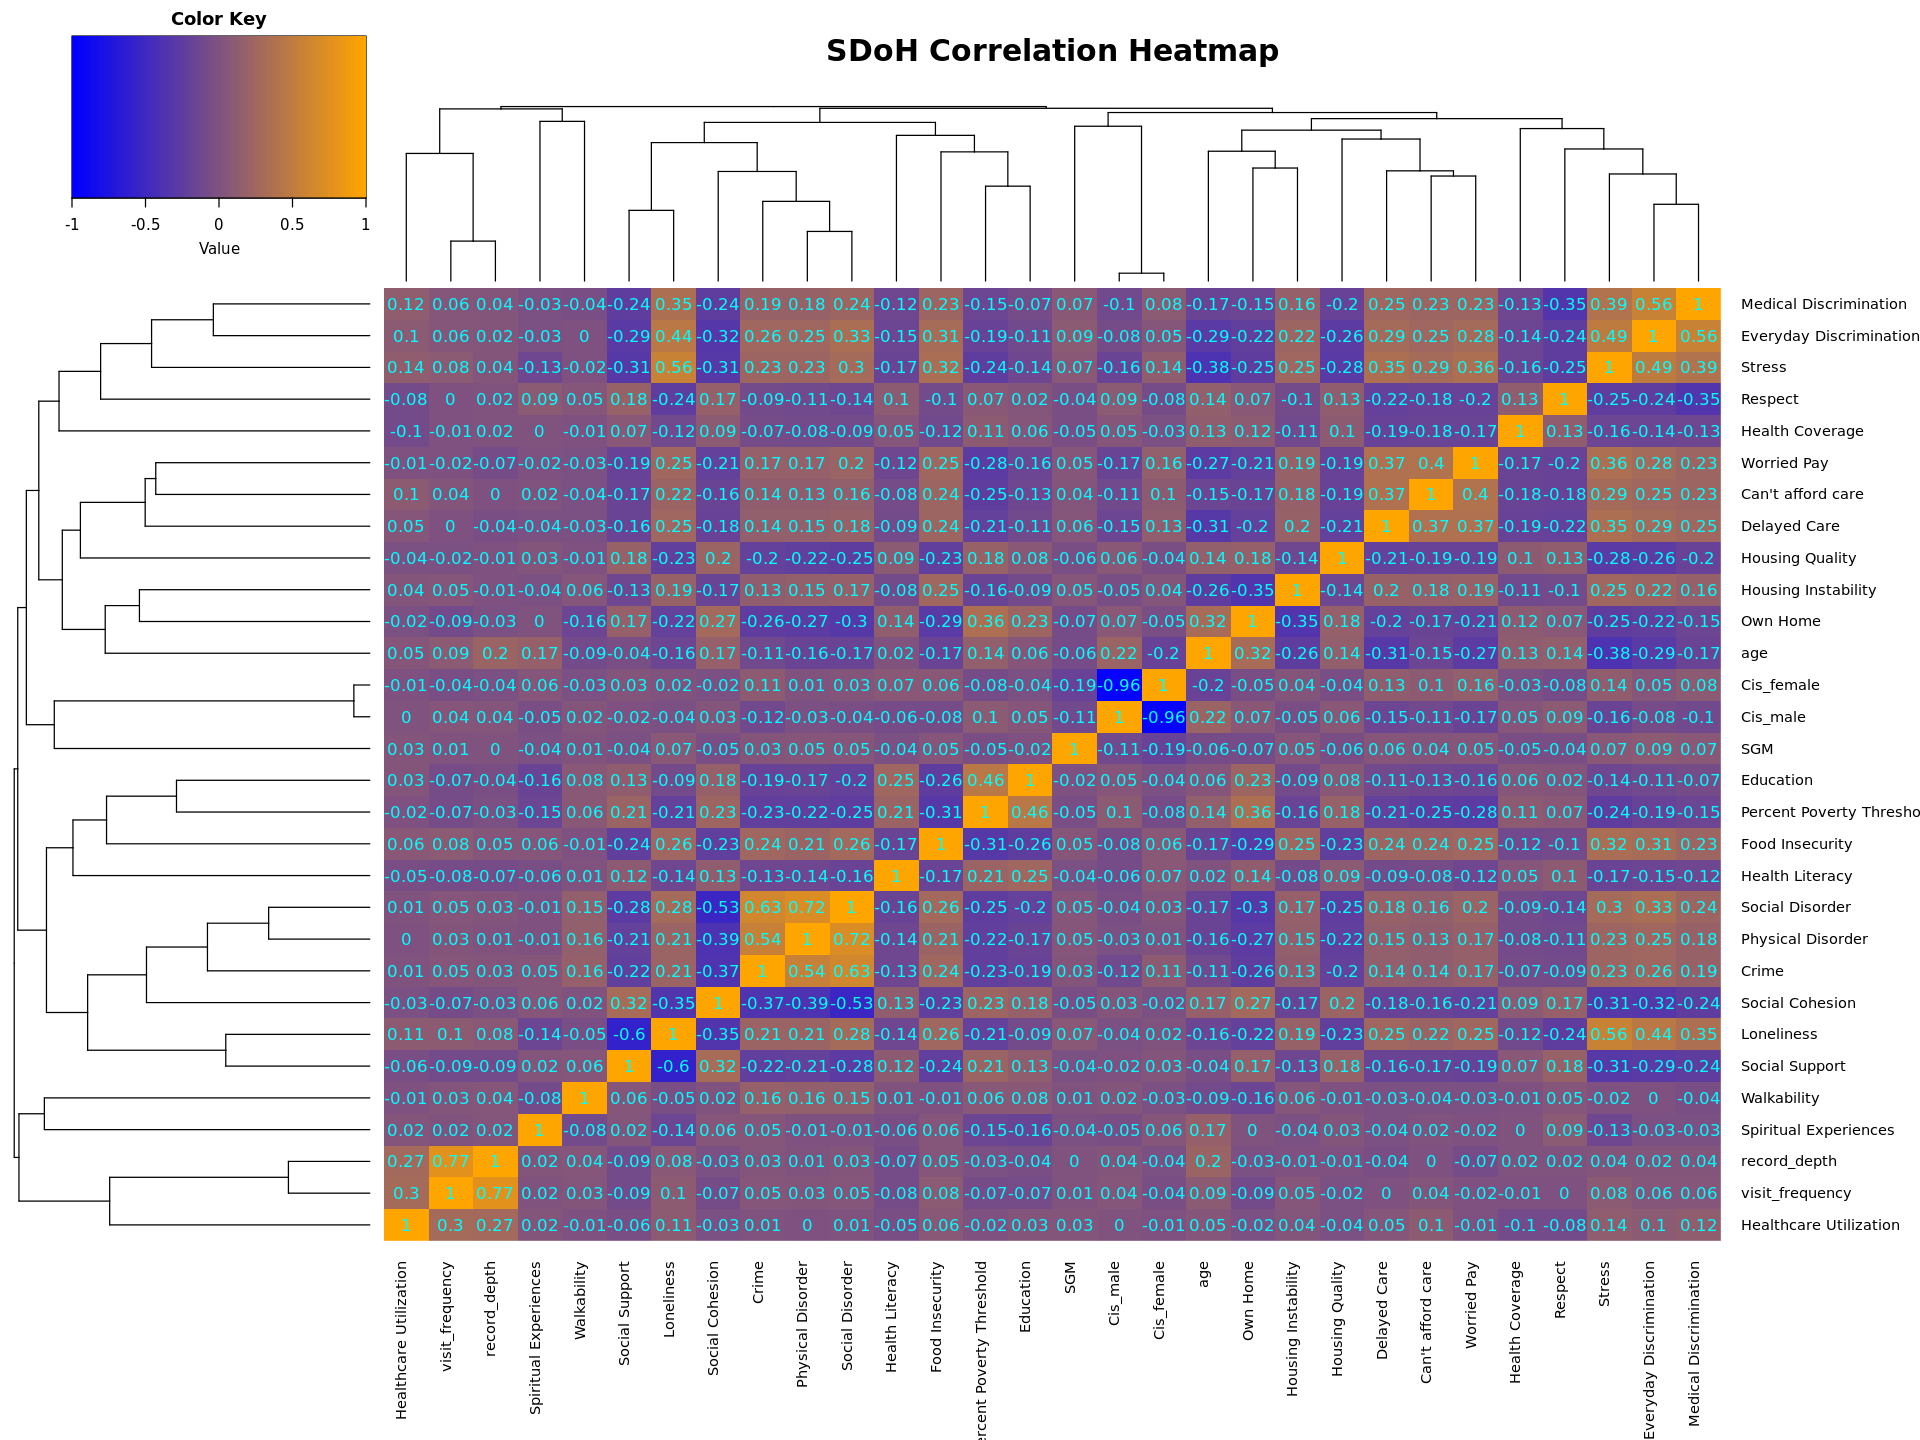

In [9]:
library(gplots)
# Define custom color palette (orange to blue gradient)
my_palette <- colorRampPalette(c("blue", "orange"))(100)

# Assuming your correlation matrix is stored in 'correlation_matrix'

options(repr.plot.width = 16, repr.plot.height = 12)  # Set width and height

cell_labels <- round(cor_matrix, 2)


# Create the heatmap
heatmap.2(cor_matrix, 
          Rowv = dend,  # Use the dendrogram for row clustering
          Colv = dend,  # Use the same dendrogram for column clustering
          dendrogram = "both",  # Show dendrogram for both rows and columns
          scale = "none",  # Do not scale data
          key = TRUE,  # Show color key
          keysize = 1.0,  # Size of color key
          trace = "none",  # Do not show trace lines
          density.info = "none",  # Do not show density plot
          cellnote = cell_labels,  # Add correlation values as labels
          margins = c(10, 10),  # Set margins
          main = "SDoH Correlation Heatmap",  # Main title
          col = my_palette  # Use custom color 
)


In [10]:
# Save as PNG
png(filename = "SDoH_Correlation_Heatmap.png", width = 1600, height = 1600, res = 100)
dev.control(displaylist = "enable")  # ✅ Ensure the plot is captured
heatmap.2(cor_matrix, 
          Rowv = dend,
          Colv = dend,
          dendrogram = "both",
          scale = "none",
          key = TRUE,
          keysize = 1.0,
          trace = "none",
          density.info = "none",
          cellnote = cell_labels,  # Add correlation values as labels
          margins = c(10, 10),
          main = "SDoH Correlation Heatmap",
          col = my_palette
)
dev.off()  # ✅ Finalize the file

pdf 
  2

# Area vs Ind

In [12]:
# This snippet assumes that you run setup first

# This code copies a file from your Google Bucket into a dataframe

# replace 'test.csv' with the name of the file in your google bucket (don't delete the quotation marks)
name_of_file_in_bucket <- 'SES_cohort.csv'

########################################################################
##
################# DON'T CHANGE FROM HERE ###############################
##
########################################################################

# Get the bucket name
my_bucket <- Sys.getenv('WORKSPACE_BUCKET')

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)

# Load the file into a dataframe

area_level<-c("no_high_school_education", "lower_median_income", "no_health_insurance",  "vacant_housing", "deprivation_index")

zip_code_socioeconomic_df  <- read_csv(name_of_file_in_bucket) |> select(c(1, area_level))

character(0)

Rows: 125295 Columns: 63
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (6): SexGender, where_born, military, healthcare, disabled, sexual_ori...
dbl  (46): person_id, race_unknown, age_today, LGBTQIA, ehr_length, relative...
lgl   (8): AIAN, Asian, Black, Mid, Multiple, PI, White, His
date  (3): date_of_birth, min_date, max_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [13]:
merged_data<-merge(sdoh_data, zip_code_socioeconomic_df, on="person_id", how="inner")
area_domains<-names(zip_code_socioeconomic_df)[-1]

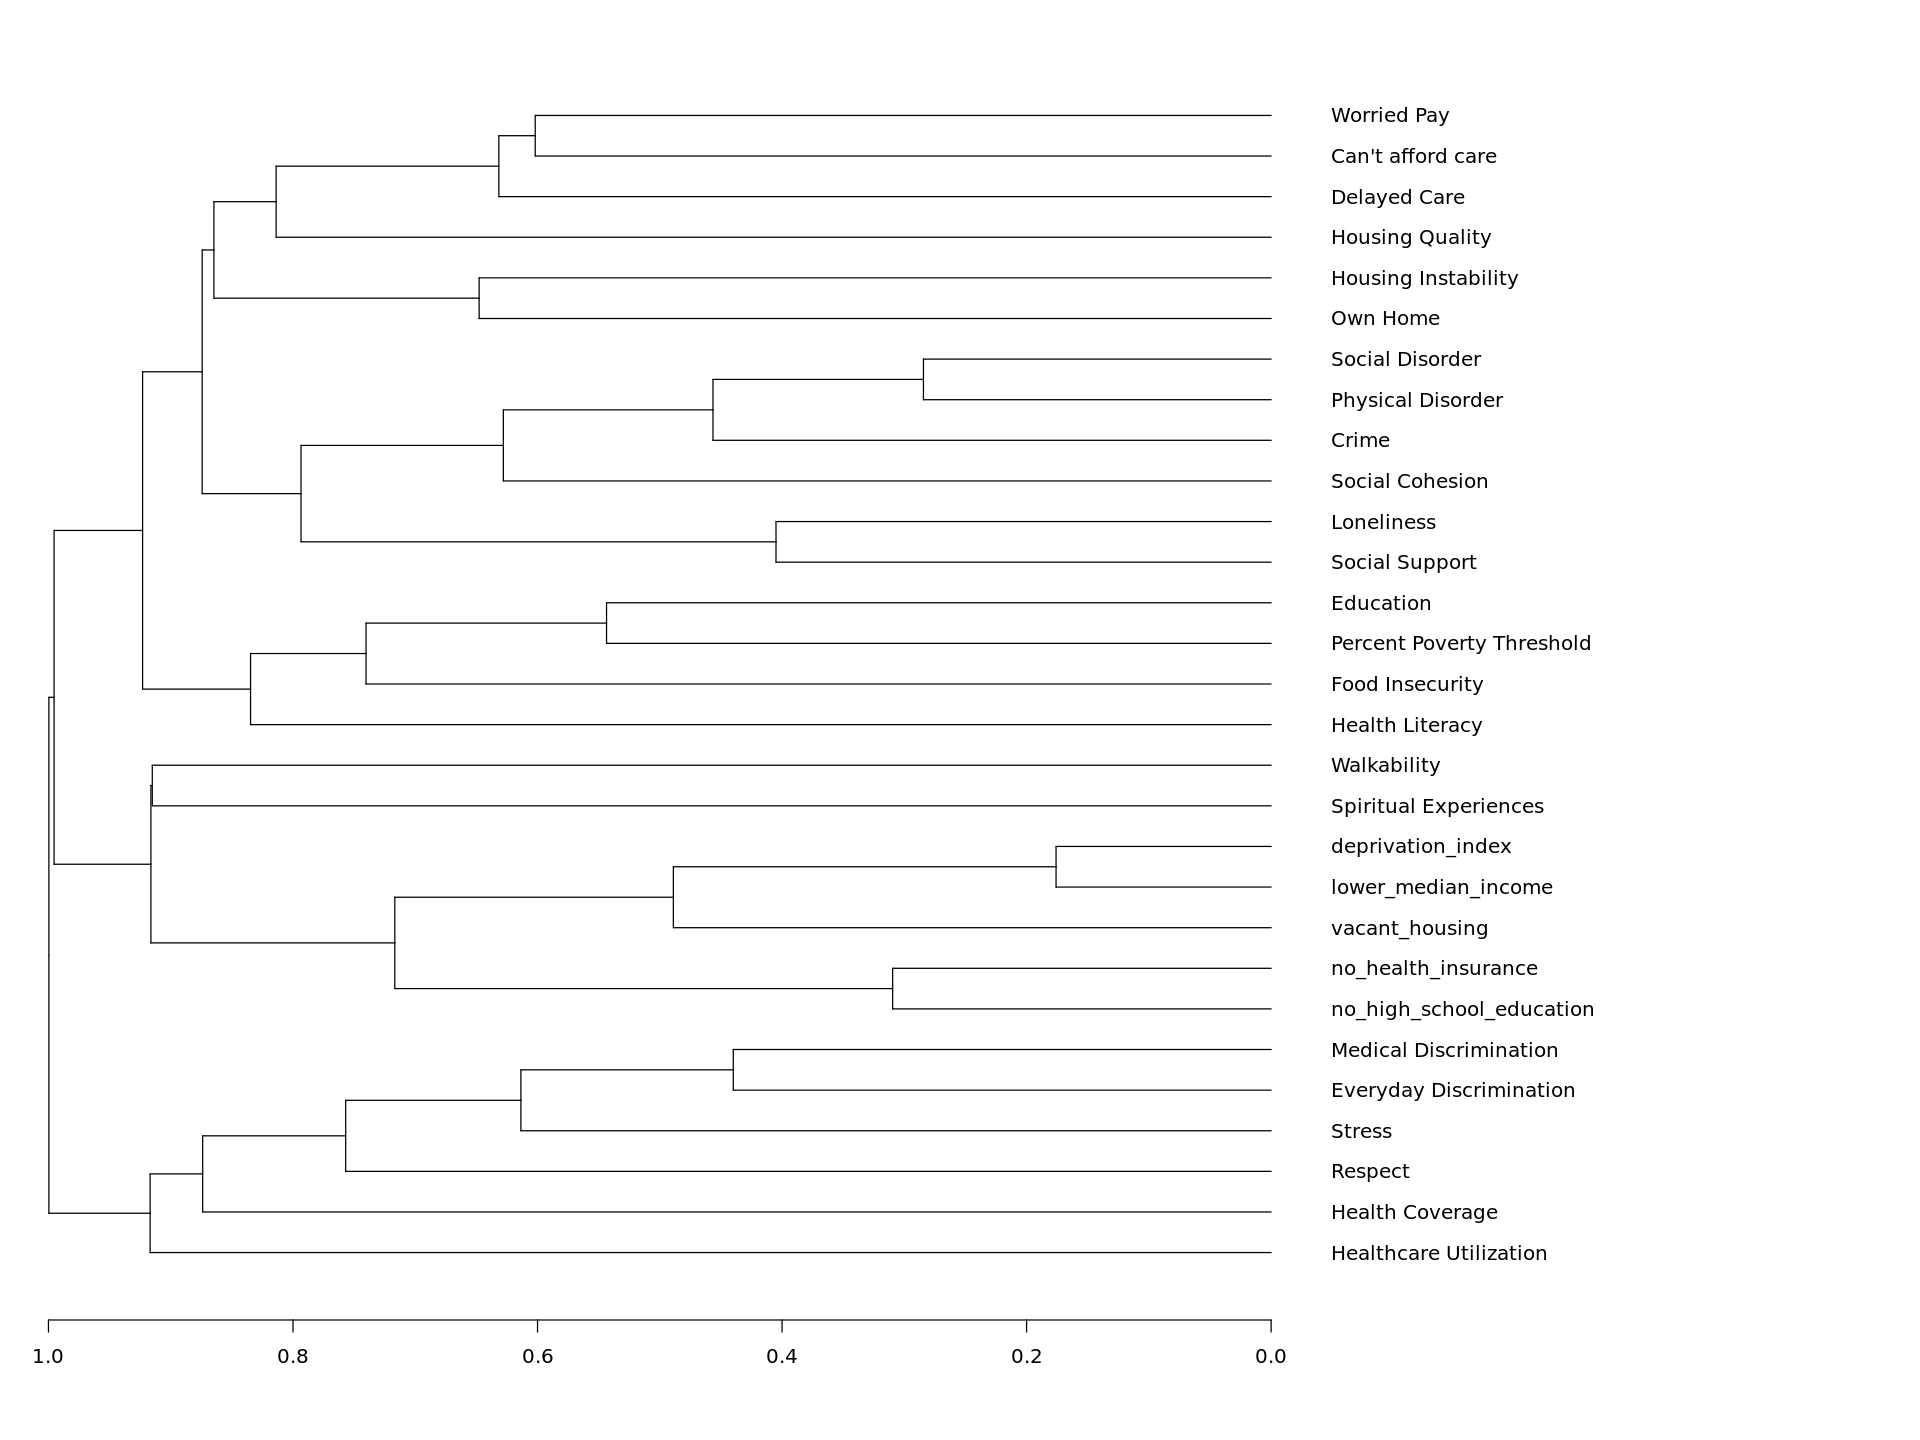

In [14]:
data_cor <- merged_data[, c(domains, area_domains)]
cor_matrix <- cor(data_cor, use = "pairwise.complete.obs")

# Compute hierarchical clustering
hc <- hclust(as.dist(1 - abs(cor_matrix)), method = "complete")

# Convert to dendrogram object
dend <- as.dendrogram(hc)

# Plot the rotated dendrogram
par(mar = c(5, 0, 2, 25))  # Adjust the margin for the bottom, left, top, and right sides respectively
plot(dend, horiz = TRUE)

In [15]:
# Assuming cor_matrix is your correlation matrix

# Get dimensions and column names of the matrix
n <- nrow(cor_matrix)
col_names <- colnames(cor_matrix)

# Get upper triangle indices (excluding diagonal)
upper_tri_indices <- which(upper.tri(cor_matrix, diag = FALSE), arr.ind = TRUE)

# Extract upper triangle values and corresponding row/column names
cor_values <- round(cor_matrix[upper_tri_indices],2)
row_names <- rownames(cor_matrix)[upper_tri_indices[, 1]]
col_names <- col_names[upper_tri_indices[, 2]]

# Combine row and column names with their respective correlation values
cor_data <- data.frame(
  Pair = paste(row_names, col_names, sep = " & "),
  Correlation = cor_values
)


pdf 
  2

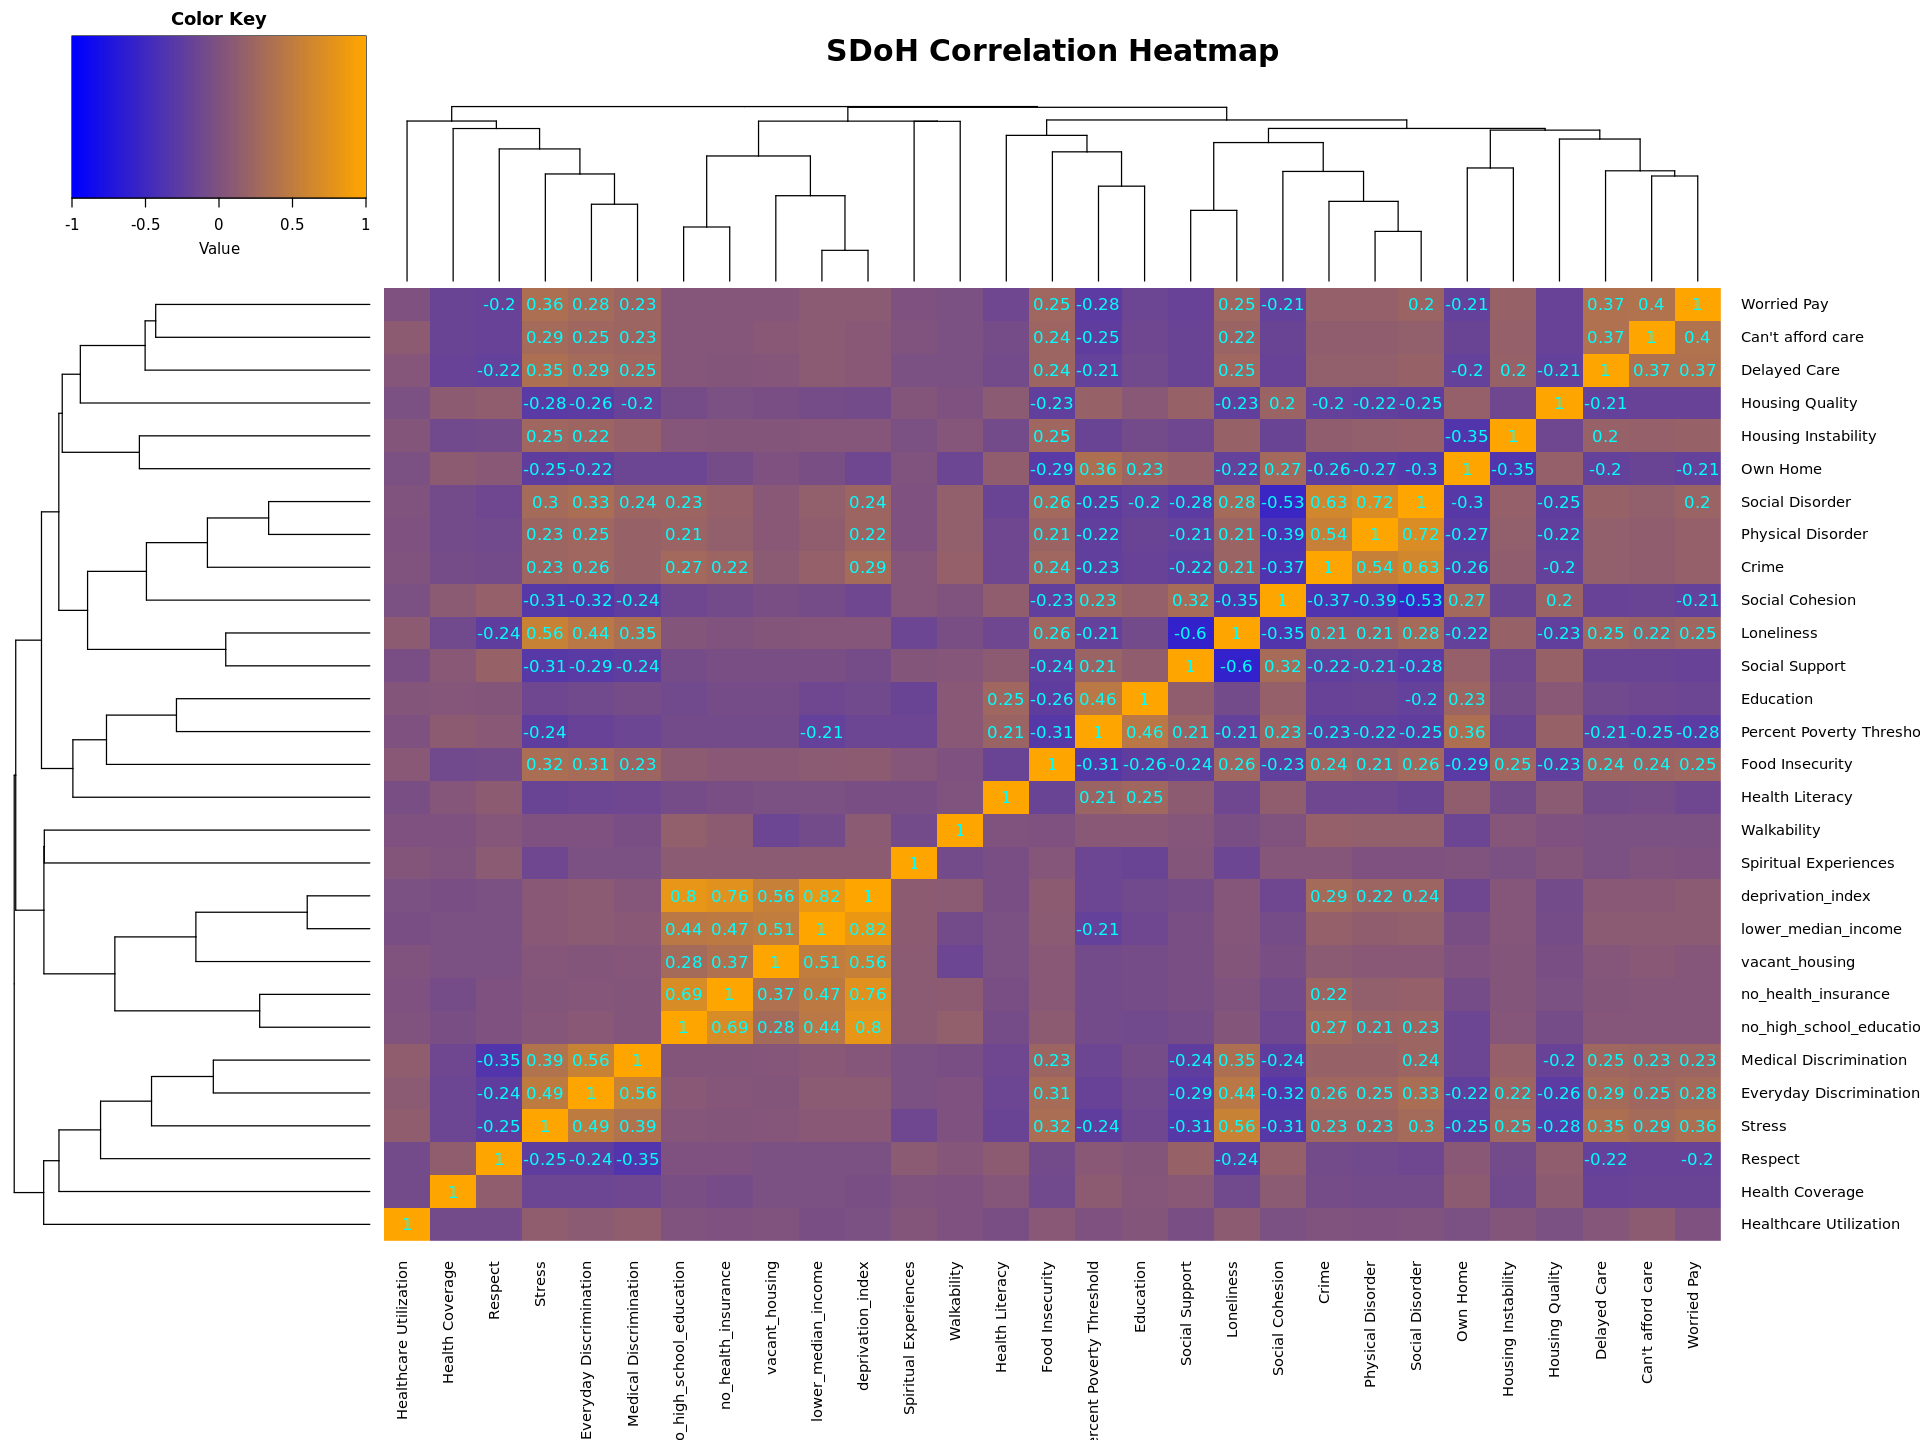

In [19]:
library(gplots)
# Define custom color palette (orange to blue gradient)
my_palette <- colorRampPalette(c("blue", "orange"))(100)

# Assuming your correlation matrix is stored in 'correlation_matrix'

options(repr.plot.width = 16, repr.plot.height = 12)  # Set width and height


cell_labels <- round(cor_matrix, 2)
cell_labels[abs(cell_labels) < 0.2] <- ""  # Remove labels below threshold



heatmap.2(cor_matrix, 
          Rowv = dend,  # Use the dendrogram for row clustering
          Colv = dend,  # Use the same dendrogram for column clustering
          dendrogram = "both",  # Show dendrogram for both rows and columns
          scale = "none",  # Do not scale data
          key = TRUE,  # Show color key
          keysize = 1.0,  # Size of color key
          trace = "none",  # Do not show trace lines
          density.info = "none",  # Do not show density plot
          cellnote = cell_labels,  # Add correlation values as labels
          margins = c(10, 10),  # Set margins
          main = "SDoH Correlation Heatmap",  # Main title
          col = my_palette  # Use custom color 
        )

png("RE_heatmap.png", width = 16, height = 12, units = "in", res = 300)

# Create the heatmap
heatmap.2(cor_matrix, 
          Rowv = dend,  # Use the dendrogram for row clustering
          Colv = dend,  # Use the same dendrogram for column clustering
          dendrogram = "both",  # Show dendrogram for both rows and columns
          scale = "none",  # Do not scale data
          key = TRUE,  # Show color key
          keysize = 1.0,  # Size of color key
          trace = "none",  # Do not show trace lines
          density.info = "none",  # Do not show density plot
          cellnote = cell_labels,  # Add correlation values as labels
          margins = c(9, 9),  # Set margins
          main = "SDoH Correlation Heatmap",  # Main title
          col = my_palette  # Use custom color 
)

dev.off()